# 01 — Data Validation

## Purpose
Before building any strategy, validate the quality of the OHLCV data.
Poor data = unreliable backtest results = wrong trading decisions.

## What this notebook covers
1. Load M5 and H1 XAUUSDT data from CSV
2. Check for gaps, duplicates, NaNs
3. Validate OHLC relationships (high >= low, close within range, etc.)
4. Inspect volume distribution
5. Visualize data coverage and quality

## Why this matters
If price data has:
- Gaps → OB strategy may detect fake displacements across the gap
- Duplicate timestamps → double-counting of bars in backtests
- OHLC violations → corrupted data from exchange API issues
- Zero volume bars → exchange maintenance or recording error

In [24]:
import sys
sys.path.insert(0, '..')  # add project root to path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('dark_background')
plt.rcParams.update({'figure.figsize': (16, 6), 'font.size': 11})

print('Libraries loaded.')

Libraries loaded.


In [25]:
# ── Load data ──────────────────────────────────────────────────────────────
SYMBOL = 'BTCUSDT'
DATA_DIR = f'../notebooks/data/{SYMBOL}'

m5 = pd.read_csv(f'{DATA_DIR}/M5/ohlcv.csv', index_col=0, parse_dates=True)
h1 = pd.read_csv(f'{DATA_DIR}/H1/ohlcv.csv', index_col=0, parse_dates=True)

# Ensure UTC timezone
if m5.index.tzinfo is None:
    m5.index = m5.index.tz_localize('UTC')
if h1.index.tzinfo is None:
    h1.index = h1.index.tz_localize('UTC')

m5 = m5.sort_index()
h1 = h1.sort_index()

print(f'M5 bars : {len(m5):,}  |  {m5.index[0]} → {m5.index[-1]}')
print(f'H1 bars : {len(h1):,}  |  {h1.index[0]} → {h1.index[-1]}')
print(f'\nM5 columns: {list(m5.columns)}')
m5.head(3)

AttributeError: 'Index' object has no attribute 'tzinfo'

In [ ]:
# ── 1. Check for NaN values ────────────────────────────────────────────────
print('=== NaN CHECK ===')
print('M5 NaNs:')
print(m5.isna().sum())
print('\nH1 NaNs:')
print(h1.isna().sum())

# Drop NaN rows if any (with count logged)
before = len(m5)
m5 = m5.dropna()
print(f'\nDropped {before - len(m5)} NaN rows from M5')

=== NaN CHECK ===
M5 NaNs:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

H1 NaNs:
open      0
high      0
low       0
close     0
volume    0
dtype: int64

Dropped 0 NaN rows from M5


In [ ]:
# ── 2. Duplicate timestamp check ───────────────────────────────────────────
print('=== DUPLICATE CHECK ===')
m5_dups = m5.index.duplicated(keep='first').sum()
h1_dups = h1.index.duplicated(keep='first').sum()
print(f'M5 duplicate timestamps: {m5_dups}')
print(f'H1 duplicate timestamps: {h1_dups}')

m5 = m5[~m5.index.duplicated(keep='first')]
h1 = h1[~h1.index.duplicated(keep='first')]

=== DUPLICATE CHECK ===
M5 duplicate timestamps: 0
H1 duplicate timestamps: 0


In [ ]:
# ── 3. OHLC relationship validation ──────────────────────────────────────
print('=== OHLC INTEGRITY CHECK ===')

violations = {
    'high < low'           : (m5['high'] < m5['low']).sum(),
    'close > high'         : (m5['close'] > m5['high']).sum(),
    'close < low'          : (m5['close'] < m5['low']).sum(),
    'open > high'          : (m5['open'] > m5['high']).sum(),
    'open < low'           : (m5['open'] < m5['low']).sum(),
    'zero/negative volume' : (m5['volume'] <= 0).sum(),
    'zero range (doji)'    : (m5['high'] == m5['low']).sum(),
}

for check, count in violations.items():
    status = '⚠️  WARNING' if count > 0 else '✅ OK'
    print(f'  {status}  |  {check}: {count} bars')

=== OHLC INTEGRITY CHECK ===
  ✅ OK  |  high < low: 0 bars
  ✅ OK  |  close > high: 0 bars
  ✅ OK  |  close < low: 0 bars
  ✅ OK  |  open > high: 0 bars
  ✅ OK  |  open < low: 0 bars
  ⚠️  WARNING  |  zero/negative volume: 55 bars
  ⚠️  WARNING  |  zero range (doji): 198 bars


In [ ]:
# ── 4. Timestamp gap detection ─────────────────────────────────────────────
print('=== GAP DETECTION ===')

m5_diff = m5.index.to_series().diff().dropna()
expected_m5 = pd.Timedelta(minutes=5)
m5_gaps = m5_diff[m5_diff > expected_m5 * 2]  # gaps > 10 min

print(f'M5 gaps larger than 10 min: {len(m5_gaps)}')
if len(m5_gaps) > 0:
    print('Largest gaps:')
    print(m5_gaps.sort_values(ascending=False).head(10))

=== GAP DETECTION ===
M5 gaps larger than 10 min: 0


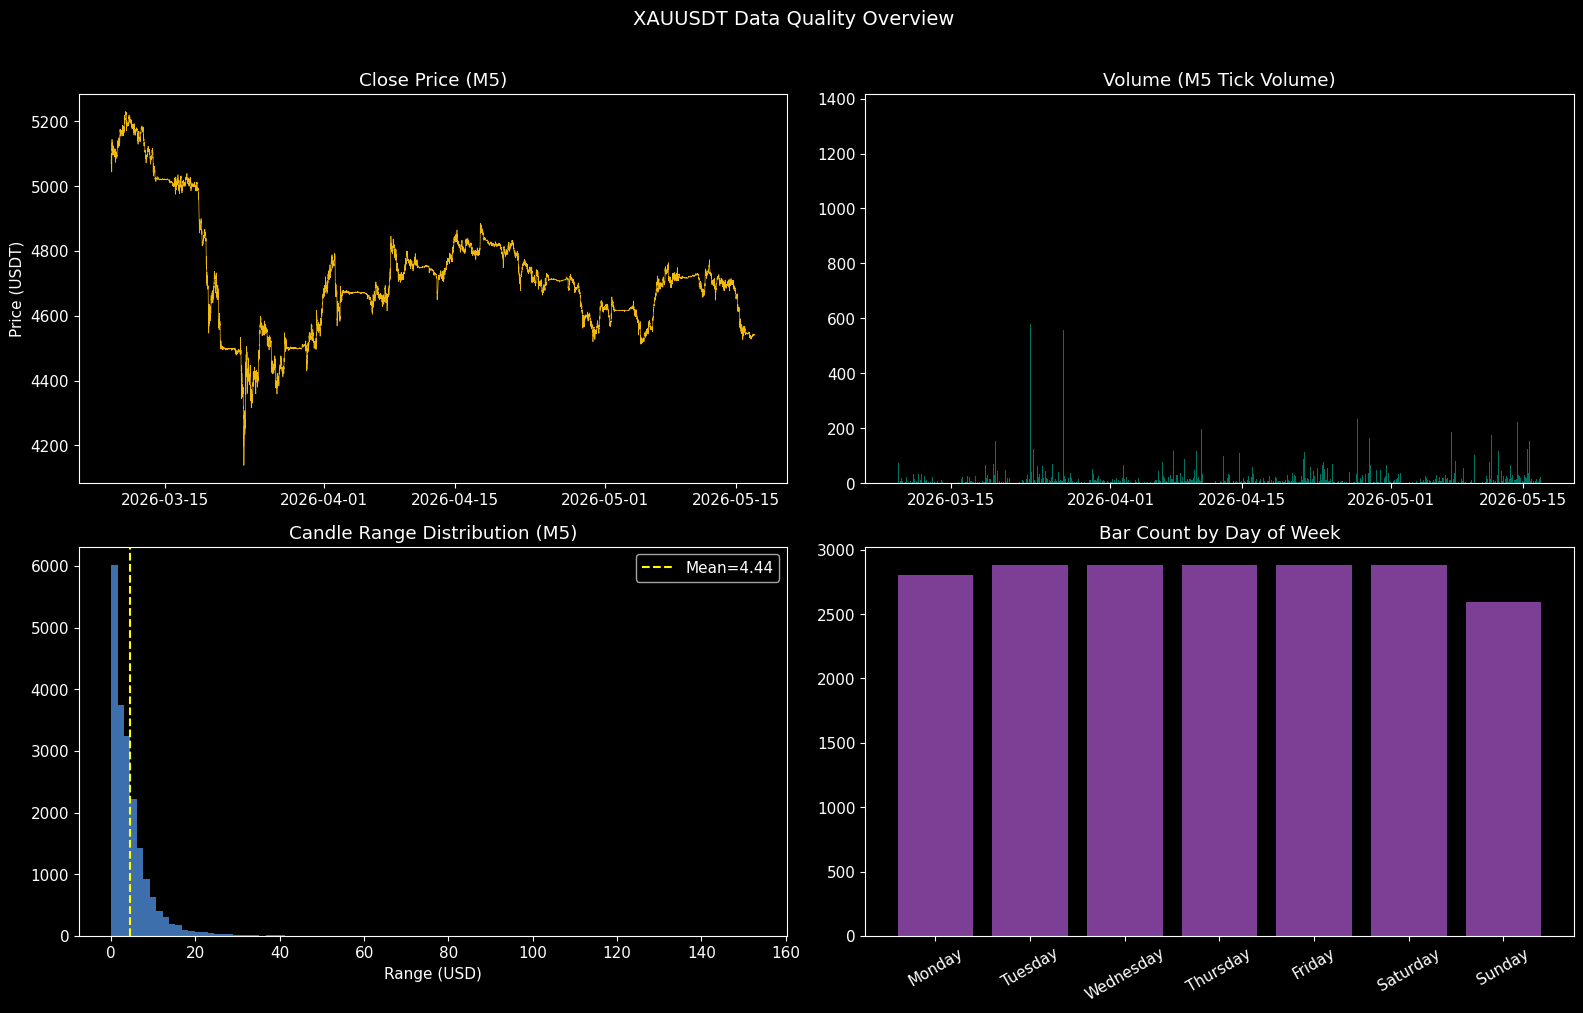

Chart saved.


In [ ]:
# ── 5. Price distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'{SYMBOL} Data Quality Overview', fontsize=14, y=1.01)

# Close price over time
axes[0, 0].plot(m5.index, m5['close'], linewidth=0.5, color='#F0B90B')
axes[0, 0].set_title('Close Price (M5)')
axes[0, 0].set_ylabel('Price (USDT)')

# Volume over time
axes[0, 1].bar(m5.index, m5['volume'], width=0.003, color='#00C0A3', alpha=0.6)
axes[0, 1].set_title('Volume (M5 Tick Volume)')

# Candle range distribution
ranges = (m5['high'] - m5['low'])
axes[1, 0].hist(ranges, bins=100, color='#4E8CD9', edgecolor='none', alpha=0.8)
axes[1, 0].axvline(ranges.mean(), color='yellow', linestyle='--', label=f'Mean={ranges.mean():.2f}')
axes[1, 0].set_title('Candle Range Distribution (M5)')
axes[1, 0].set_xlabel('Range (USD)')
axes[1, 0].legend()

# Bar count by day-of-week
dow = m5.index.day_name()
dow_counts = dow.value_counts().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
axes[1, 1].bar(dow_counts.index, dow_counts.values, color='#9D50BB', alpha=0.8)
axes[1, 1].set_title('Bar Count by Day of Week')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../notebooks_ob/results/01_data_validation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Chart saved.')

In [ ]:
# ── 6. Summary statistics ──────────────────────────────────────────────────
print('=== SUMMARY STATISTICS ===')
print(m5.describe().round(4))

print('\n=== CONCLUSION ===')
total_issues = sum(violations.values()) + len(m5_gaps) + m5_dups
if total_issues == 0:
    print('✅ Data passes all quality checks — ready for strategy research.')
else:
    print(f'⚠️  {total_issues} issues found — review before running backtests.')

=== SUMMARY STATISTICS ===
             open        high         low       close      volume
count  19798.0000  19798.0000  19798.0000  19798.0000  19798.0000
mean    4718.1960   4720.3664   4715.9235   4718.1692     18.6888
std      180.1721    179.7707    180.6144    180.1592     37.8730
min     4137.8000   4156.8000   4121.0000   4137.8000      0.0000
25%     4612.0550   4614.9625   4609.0650   4611.9850      2.1125
50%     4706.6100   4708.0600   4704.5100   4706.6050      7.5635
75%     4790.5200   4792.8975   4788.4275   4790.5150     20.4178
max     5230.6800   5233.5400   5226.8700   5230.6800   1350.0670

=== CONCLUSION ===
⚠️  253 issues found — review before running backtests.
